# Chapter 11: The Cotangent Bundle

**Source Span.** *Introduction to Smooth Manifolds*, Chapter 11, printed pages 272-303. I inspected roughly PDF pages 290-321 with `pdftotext -layout`, including Covectors, Tangent Covectors on Manifolds, Covector Fields, The Differential of a Function, Pullbacks of Covector Fields, Restricting Covector Fields to Submanifolds, Line Integrals, Conservative Covector Fields, closed covector fields, the Poincare lemma for covector fields, and the end-of-chapter problems.

**Chapter goal.** Learn to read a covector field as a smoothly varying measuring device on tangent vectors: coordinate covectors form the local basis, `df` is the coordinate-free derivative of a real-valued function, pullbacks move covectors contravariantly, and line integrals reveal the difference between exact, conservative, closed, and globally non-exact fields.

The source is used only for structure, terminology, theorem orientation, examples to cover, and page span. The explanations, code, diagrams, and checks below are original notebook material.


## Computational Translation Guide

| Smooth-manifold idea | Computational object here | What to inspect |
| --- | --- | --- |
| Covector in `T_p^*M` | row vector plus its kernel and unit affine line | covectors measure vectors; they are not arrows until a metric is chosen |
| Coordinate covectors `dx^i` | dual basis and Jacobian-transpose rules | components change by pullback, not by the vector rule |
| Differential `df` | row of partial derivatives | linear approximation to `f(p+v)-f(p)` |
| Pullback `F^* omega` | substitute component functions of `F`, then differentiate | the map goes from codomain covectors to domain covectors |
| Line integral | integrate `omega_gamma(t)(gamma'(t)) dt` | exact fields depend only on endpoints; angular fields remember winding |
| Closed vs exact | symbolic curl-like residual plus loop integrals | local equations do not erase global topology |
| Chapter 10 and Chapter 13 links | dual transition functions and metric flat/sharp maps | `T^*M` is a dual vector bundle; metrics add a noncanonical vector-covector bridge |


## Planner Pass: Visual Storyboard and Library Routing

| Storyboard item | Representation | Library route | Artifact target | Validation target |
| --- | --- | --- | --- | --- |
| Covector as hyperplane measurement | kernels and `omega(v)=1` lines in three tangent spaces | Matplotlib and NumPy | `figures/covector-kernel-unit-hyperplanes.png` | pairing values on kernel/unit lines |
| Coordinate covectors and basis changes | polar pullback table plus pairing invariance | SymPy, NumPy, CSV | `tables/coordinate-covector-transformations.csv` | `x dy - y dx = r^2 dtheta`, pairing invariant under `J^T` |
| `df` as best linear approximation | contours, kernel of `df_p`, residual decay | Matplotlib and NumPy | `figures/differential-linear-approximation.png` | residual is second order in step size |
| Pullback of covector fields | chain-rule diagram and symbolic pullback | NetworkX and SymPy | `figures/pullback-chain-rule-diagram.png` | `F^*(dh)=d(h o F)` component equality |
| Line integrals and exactness | exact-field paths versus angular loops | Matplotlib, NumPy, Plotly | `figures/line-integrals-exact-vs-angular.png`, `html/angular-form-winding-line-integrals.html` | endpoint dependence for exact fields, `2*pi` winding for angular field |
| Closed, exact, conservative classifier | table of representative fields | SymPy, CSV | `tables/closed-exact-conservative-classification.csv` | closed residuals and loop obstructions agree |
| Vector bundle and metric bridge | dual transition matrix and flat/sharp metric maps | NumPy, Matplotlib, CSV | `figures/dual-bundle-metric-bridge.png` | inverse-transpose and metric inverse identities |

Matplotlib is used where fixed 2D geometry must be legible in static course artifacts. Plotly is used for the winding-number exploration because the cumulative integral is best inspected as a height over a loop. SymPy handles exact coordinate and pullback identities. NetworkX is used only for the pullback dependency diagram, where the graph is a proof scaffold rather than decoration.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp


def locate_book_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        course = candidate / "Introduction-to-Smooth-Manifolds"
        if (course / "AGENTS.md").exists() and (course / "source_map.json").exists():
            return course
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds course root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-11-the-cotangent-bundle"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

SOURCE_SPAN = {
    "printed_pages": "272-303",
    "pdf_pages_inspected": "290-321",
    "pdftotext_command": "pdftotext -f 290 -l 321 -layout 'Introduction to Smooth Manifolds.pdf' -",
}

chapter_terms = {
    "covectors",
    "cotangent spaces",
    "differential of a function",
    "coordinate covectors",
    "basis changes",
    "pullbacks",
    "line integrals",
    "exact covector fields",
    "conservative covector fields",
    "closed non-exact covector fields",
    "Chapter 10 vector bundles",
    "Chapter 13 metrics",
}

artifacts: list[Path] = []
check_paths: list[Path] = []
computed_checks: dict[str, object] = {}


def artifact_record(path: Path) -> dict[str, object]:
    path = Path(path)
    return {
        "path": path.relative_to(BOOK_ROOT).as_posix(),
        "bytes": path.stat().st_size if path.exists() else 0,
    }


def save_plotly_standalone(fig: go.Figure, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_html(str(path), include_plotlyjs="inline", full_html=True)
    return path


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-11-the-cotangent-bundle


## 1. Covectors as Measuring Hyperplanes

A nonzero covector `omega_p` on a two-dimensional tangent space is visible from two parallel lines: the kernel `omega_p(v)=0`, and the affine line `omega_p(v)=1`. Vectors crossing these lines are not being projected by a metric; they are being evaluated by a linear functional. The picture below draws three fibers of `T^*M` over three base points and shows how the measuring line can vary smoothly from point to point.


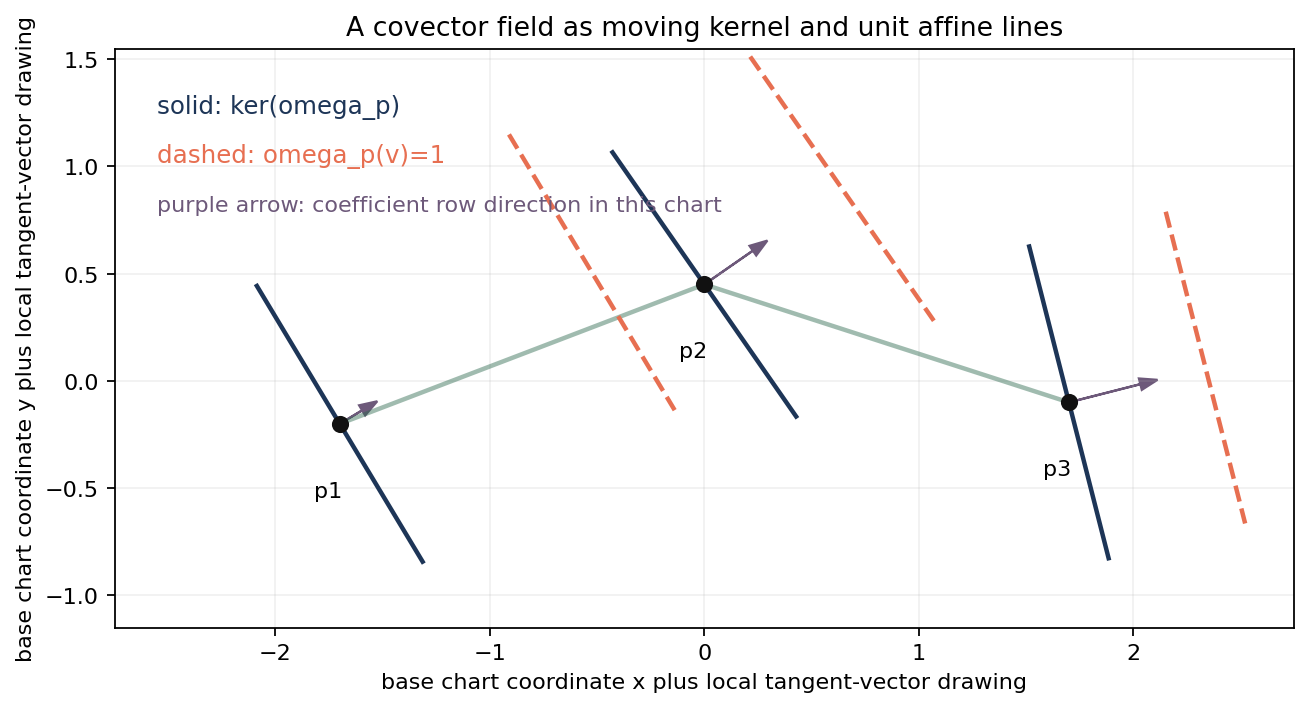

In [2]:
def covector_components(base_x: float) -> np.ndarray:
    return np.array([1.05 + 0.25 * base_x, 0.55 + 0.18 * np.cos(1.7 * base_x)], dtype=float)


base_points = np.array([[-1.7, -0.2], [0.0, 0.45], [1.7, -0.1]])
local_s = np.linspace(-0.75, 0.75, 200)
fig, ax = plt.subplots(figsize=(10.5, 4.7))
ax.plot(base_points[:, 0], base_points[:, 1], color="#2d6a4f", linewidth=2.0, alpha=0.45)

pairing_checks = []
for idx, p in enumerate(base_points):
    omega = covector_components(float(p[0]))
    a, b = omega
    kernel_dir = np.array([b, -a], dtype=float)
    kernel_dir = kernel_dir / np.linalg.norm(kernel_dir)
    normal = omega / np.dot(omega, omega)
    kernel_line = p + np.outer(local_s, kernel_dir)
    unit_line = p + normal + np.outer(local_s, kernel_dir)
    pairing_checks.append({
        "fiber_index": idx,
        "omega": omega.tolist(),
        "kernel_pairing_abs": float(abs(np.dot(omega, kernel_dir * 0.37))),
        "unit_pairing_error": float(abs(np.dot(omega, normal - 0.21 * kernel_dir) - 1.0)),
    })
    ax.plot(kernel_line[:, 0], kernel_line[:, 1], color="#1d3557", linewidth=2.0)
    ax.plot(unit_line[:, 0], unit_line[:, 1], color="#e76f51", linewidth=2.0, linestyle="--")
    ax.scatter([p[0]], [p[1]], s=45, color="#111111", zorder=3)
    ax.arrow(p[0], p[1], 0.28 * omega[0], 0.28 * omega[1], head_width=0.055, color="#6d597a", length_includes_head=True)
    ax.text(p[0] - 0.12, p[1] - 0.34, f"p{idx+1}", fontsize=10)

ax.text(-2.55, 1.25, "solid: ker(omega_p)", color="#1d3557", fontsize=11)
ax.text(-2.55, 1.02, "dashed: omega_p(v)=1", color="#e76f51", fontsize=11)
ax.text(-2.55, 0.79, "purple arrow: coefficient row direction in this chart", color="#6d597a", fontsize=10)
ax.set_title("A covector field as moving kernel and unit affine lines")
ax.set_xlabel("base chart coordinate x plus local tangent-vector drawing")
ax.set_ylabel("base chart coordinate y plus local tangent-vector drawing")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.75, 2.75)
ax.set_ylim(-1.15, 1.55)
ax.grid(True, alpha=0.18)

covector_fig = save_matplotlib(fig, FIGURES / "covector-kernel-unit-hyperplanes.png")
plt.close(fig)
artifacts.append(covector_fig)

max_kernel = max(row["kernel_pairing_abs"] for row in pairing_checks)
max_unit = max(row["unit_pairing_error"] for row in pairing_checks)
covector_check_path = save_json({
    "description": "Covector kernels evaluate to zero and unit affine lines evaluate to one.",
    "fiber_checks": pairing_checks,
    "max_kernel_pairing_abs": max_kernel,
    "max_unit_pairing_error": max_unit,
}, CHECKS / "covector-pairing-hyperplane-checks.json")
check_paths.append(covector_check_path)
computed_checks["covector_kernel_pairing"] = max_kernel < 1e-12
computed_checks["covector_unit_affine_pairing"] = max_unit < 1e-12
display_artifact(covector_fig, width=850)


The object attached to `p` is a member of the dual vector space `T_p^*M`. In Chapter 10 language, the fibers are vector spaces and the local trivializations are controlled by transition functions. In this chapter the transition functions are the dual ones, so the components of a covector move by Jacobian-transpose rules.


## 2. Coordinate Covectors and Basis Changes

In polar coordinates on the right half-plane, `x = r cos(theta)` and `y = r sin(theta)`. The coordinate covectors transform by pullback. Thus `dx` and `dy` are obtained by differentiating coordinate functions, and a covector component row pulls back by `J.T`.


In [3]:
r, theta = sp.symbols("r theta", positive=True, real=True)
x_expr = r * sp.cos(theta)
y_expr = r * sp.sin(theta)
J = sp.Matrix([[sp.diff(x_expr, r), sp.diff(x_expr, theta)], [sp.diff(y_expr, r), sp.diff(y_expr, theta)]])

omega_xy = sp.Matrix([-y_expr, x_expr])
pullback_xdy_minus_ydx = sp.simplify(J.T * omega_xy)
angular_components_xy = sp.Matrix([-y_expr / (x_expr**2 + y_expr**2), x_expr / (x_expr**2 + y_expr**2)])
pullback_angular = sp.simplify(J.T * angular_components_xy)

basis_rows = [
    {"object": "dx", "polar_expression": f"{sp.diff(x_expr, r)} dr + ({sp.diff(x_expr, theta)}) dtheta"},
    {"object": "dy", "polar_expression": f"{sp.diff(y_expr, r)} dr + {sp.diff(y_expr, theta)} dtheta"},
    {"object": "x dy - y dx", "polar_expression": f"{pullback_xdy_minus_ydx[0]} dr + {pullback_xdy_minus_ydx[1]} dtheta"},
    {"object": "(-y dx + x dy)/(x^2+y^2)", "polar_expression": f"{pullback_angular[0]} dr + {pullback_angular[1]} dtheta"},
]
coordinate_table_path = save_csv(basis_rows, TABLES / "coordinate-covector-transformations.csv")
artifacts.append(coordinate_table_path)

J_num = np.array(J.subs({r: 1.4, theta: 0.73})).astype(float)
v_new = np.array([0.35, -0.8])
omega_old = np.array([1.2, -0.4])
pairing_error = float(abs(omega_old @ (J_num @ v_new) - (J_num.T @ omega_old) @ v_new))

coordinate_check_path = save_json({
    "jacobian_xy_with_respect_to_r_theta": str(J),
    "pullback_xdy_minus_ydx_components": [str(sp.simplify(c)) for c in pullback_xdy_minus_ydx],
    "pullback_angular_components": [str(sp.simplify(c)) for c in pullback_angular],
    "pairing_error_numeric": pairing_error,
}, CHECKS / "coordinate-covector-basis-change.json")
check_paths.append(coordinate_check_path)
computed_checks["polar_xdy_minus_ydx"] = (sp.simplify(pullback_xdy_minus_ydx[0]) == 0 and sp.simplify(pullback_xdy_minus_ydx[1] - r**2) == 0)
computed_checks["polar_angular_form"] = (sp.simplify(pullback_angular[0]) == 0 and sp.simplify(pullback_angular[1] - 1) == 0)
computed_checks["coordinate_pairing_invariance"] = pairing_error < 1e-12
pd.DataFrame(basis_rows)


,object,polar_expression
0,dx,cos(theta) dr + (-r*sin(theta)) dtheta
1,dy,sin(theta) dr + r*cos(theta) dtheta
2,x dy - y dx,0 dr + r**2 dtheta
3,(-y dx + x dy)/(x^2+y^2),0 dr + 1 dtheta


The row `(-y dx + x dy)/(x^2+y^2) = dtheta` is local: it is valid on a polar-coordinate chart, not on the whole punctured plane as a single-valued potential. That local/global tension becomes the main example later in the chapter.


## 3. The Differential of a Function

For a smooth real-valued function, `df_p(v)` is the derivative of `f` in the direction `v`. In coordinates it is the row of partial derivatives, but the definition does not require coordinates: apply the tangent vector `v` as a derivation to `f`. The next artifact checks that `df_p(hv)` is the first-order part of `f(p+hv)-f(p)`.


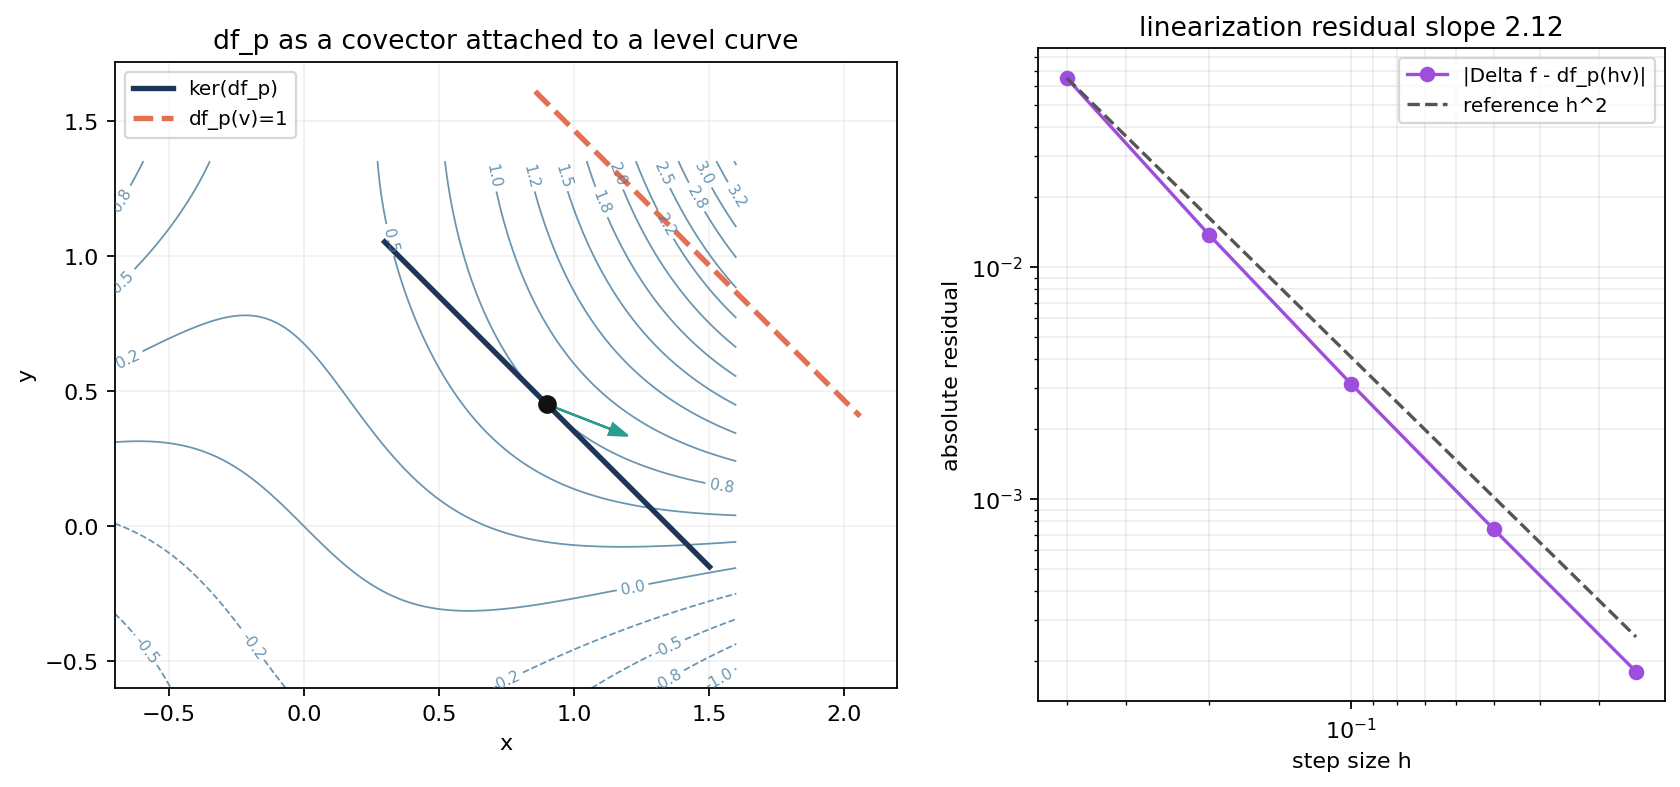

In [4]:
def f_np(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return x**2 * y + 0.4 * np.sin(x + y)


p = np.array([0.9, 0.45])
direction = np.array([0.72, -0.28])
direction = direction / np.linalg.norm(direction)
grad_p = np.array([2 * p[0] * p[1] + 0.4 * math.cos(p[0] + p[1]), p[0] ** 2 + 0.4 * math.cos(p[0] + p[1])])

xs = np.linspace(-0.7, 1.6, 220)
ys = np.linspace(-0.6, 1.35, 220)
X, Y = np.meshgrid(xs, ys)
Z = f_np(X, Y)

kernel_dir = np.array([grad_p[1], -grad_p[0]])
kernel_dir = kernel_dir / np.linalg.norm(kernel_dir)
unit_offset = grad_p / np.dot(grad_p, grad_p)
line_s = np.linspace(-0.85, 0.85, 200)
kernel_line = p + np.outer(line_s, kernel_dir)
unit_line = p + unit_offset + np.outer(line_s, kernel_dir)

hs = np.array([0.4, 0.2, 0.1, 0.05, 0.025])
actual = np.array([f_np(p[0] + h * direction[0], p[1] + h * direction[1]) - f_np(p[0], p[1]) for h in hs])
linear = np.array([h * float(grad_p @ direction) for h in hs])
residuals = np.abs(actual - linear)
residual_order = float(np.polyfit(np.log(hs), np.log(residuals), 1)[0])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.5, 5.3), gridspec_kw={"width_ratios": [1.25, 1.0]})
levels = ax0.contour(X, Y, Z, levels=18, colors="#457b9d", linewidths=0.8, alpha=0.8)
ax0.clabel(levels, inline=True, fontsize=7, fmt="%.1f")
ax0.plot(kernel_line[:, 0], kernel_line[:, 1], color="#1d3557", linewidth=2.4, label="ker(df_p)")
ax0.plot(unit_line[:, 0], unit_line[:, 1], color="#e76f51", linewidth=2.4, linestyle="--", label="df_p(v)=1")
ax0.scatter([p[0]], [p[1]], color="#111111", s=55, zorder=4)
ax0.arrow(p[0], p[1], 0.32 * direction[0], 0.32 * direction[1], head_width=0.045, color="#2a9d8f", length_includes_head=True)
ax0.set_title("df_p as a covector attached to a level curve")
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_aspect("equal", adjustable="box")
ax0.legend(loc="upper left", fontsize=9)
ax0.grid(True, alpha=0.16)

ax1.loglog(hs, residuals, marker="o", color="#9d4edd", label="|Delta f - df_p(hv)|")
ax1.loglog(hs, residuals[0] * (hs / hs[0]) ** 2, linestyle="--", color="#555555", label="reference h^2")
ax1.invert_xaxis()
ax1.set_xlabel("step size h")
ax1.set_ylabel("absolute residual")
ax1.set_title(f"linearization residual slope {residual_order:.2f}")
ax1.grid(True, which="both", alpha=0.22)
ax1.legend(fontsize=9)

linearization_fig = save_matplotlib(fig, FIGURES / "differential-linear-approximation.png")
plt.close(fig)
artifacts.append(linearization_fig)
linearization_check_path = save_json({
    "point": p.tolist(),
    "df_components_at_point": grad_p.tolist(),
    "direction": direction.tolist(),
    "step_sizes": hs.tolist(),
    "actual_delta_f": actual.tolist(),
    "linear_part_df_p_hv": linear.tolist(),
    "residuals": residuals.tolist(),
    "loglog_residual_order": residual_order,
}, CHECKS / "differential-linear-approximation.json")
check_paths.append(linearization_check_path)
computed_checks["differential_residual_second_order"] = residual_order > 1.85
display_artifact(linearization_fig, width=920)


This is why the chapter treats the differential as a covector field rather than as a vector field. A Chapter 13 metric can convert this covector into a gradient vector, but the differential itself does not need that extra structure.


## 4. Pullbacks of Covectors and Covector Fields

A smooth map `F: M -> N` pushes tangent vectors forward by `dF_p`. Dualizing reverses direction: covectors on `N` pull back to covectors on `M`. That reversal is exactly what lets `F^* dh = d(h o F)` hold for every real-valued function `h` on `N`.


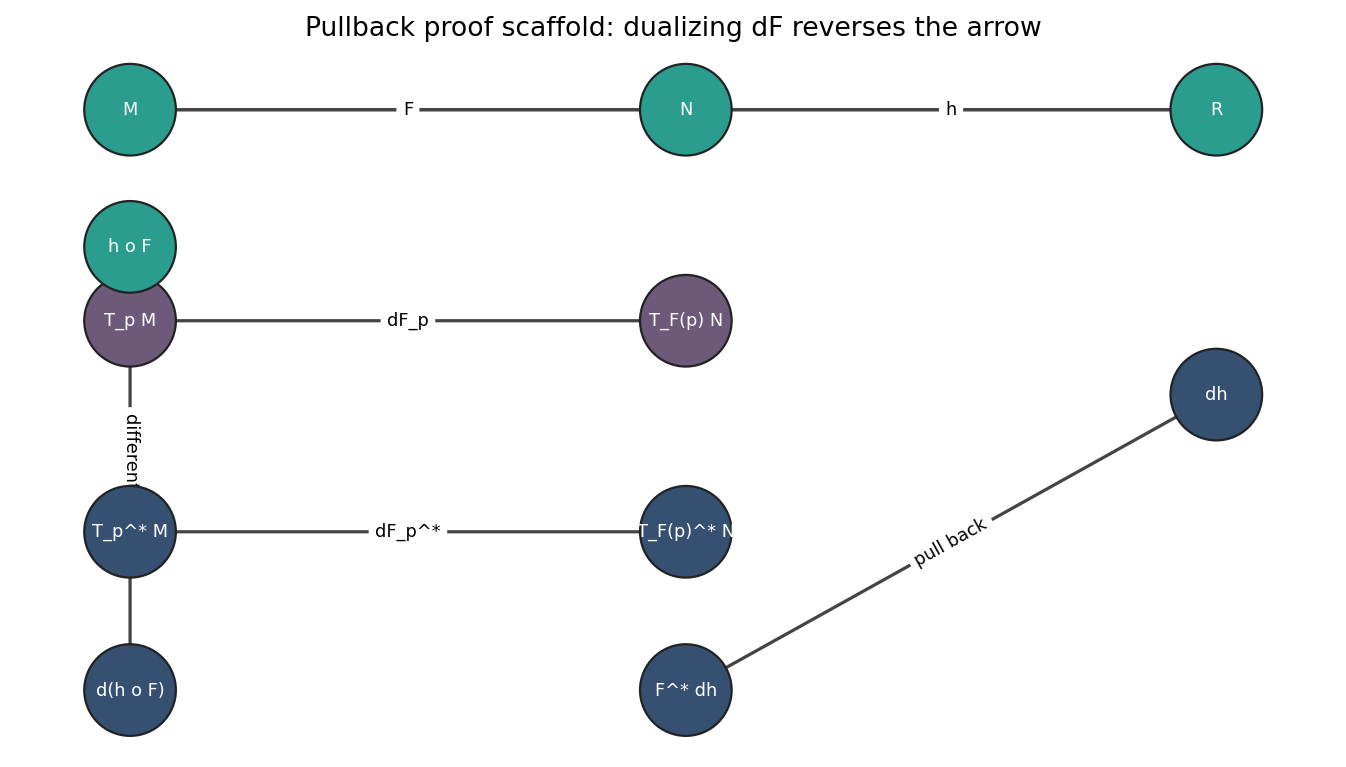

In [5]:
s, t = sp.symbols("s t", real=True)
u, v = sp.symbols("u v", real=True)
F_u = s + t**2
F_v = sp.exp(s - t)
h = u**2 * v + sp.sin(v)
dh_uv = sp.Matrix([sp.diff(h, u), sp.diff(h, v)])
J_F = sp.Matrix([[sp.diff(F_u, s), sp.diff(F_u, t)], [sp.diff(F_v, s), sp.diff(F_v, t)]])
pullback_dh = sp.simplify(J_F.T * dh_uv.subs({u: F_u, v: F_v}))
d_h_after_F = sp.Matrix([sp.diff(h.subs({u: F_u, v: F_v}), s), sp.diff(h.subs({u: F_u, v: F_v}), t)])
pullback_residual = [sp.simplify(a - b) for a, b in zip(pullback_dh, d_h_after_F)]

pullback_rows = [
    {"component": "ds", "F_star_dh": str(sp.simplify(pullback_dh[0])), "d_h_o_F": str(sp.simplify(d_h_after_F[0])), "difference": str(pullback_residual[0])},
    {"component": "dt", "F_star_dh": str(sp.simplify(pullback_dh[1])), "d_h_o_F": str(sp.simplify(d_h_after_F[1])), "difference": str(pullback_residual[1])},
]
pullback_table_path = save_csv(pullback_rows, TABLES / "pullback-chain-rule-components.csv")
artifacts.append(pullback_table_path)

D = nx.DiGraph()
D.add_edges_from([
    ("M", "N", {"label": "F"}),
    ("N", "R", {"label": "h"}),
    ("M", "R", {"label": "h o F"}),
    ("T_p M", "T_F(p) N", {"label": "dF_p"}),
    ("T_F(p)^* N", "T_p^* M", {"label": "dF_p^*"}),
    ("dh", "F^* dh", {"label": "pull back"}),
    ("h o F", "d(h o F)", {"label": "differentiate"}),
])
pos = {"M": (0, 1), "N": (2.2, 1), "R": (4.3, 1), "T_p M": (0, 0), "T_F(p) N": (2.2, 0), "T_F(p)^* N": (2.2, -1), "T_p^* M": (0, -1), "dh": (4.3, -0.35), "F^* dh": (2.2, -1.75), "h o F": (0, 0.35), "d(h o F)": (0, -1.75)}
fig, ax = plt.subplots(figsize=(10.6, 5.7))
node_colors = ["#355070" if "^*" in n or n.startswith("d") else "#6d597a" if n.startswith("T") else "#2a9d8f" for n in D.nodes]
nx.draw_networkx_nodes(D, pos, ax=ax, node_color=node_colors, node_size=1700, edgecolors="#222222", linewidths=1.0)
nx.draw_networkx_labels(D, pos, ax=ax, font_size=8, font_color="white")
nx.draw_networkx_edges(D, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.45, edge_color="#444444")
nx.draw_networkx_edge_labels(D, pos, edge_labels={(a, b): data["label"] for a, b, data in D.edges(data=True)}, ax=ax, font_size=8)
ax.set_title("Pullback proof scaffold: dualizing dF reverses the arrow")
ax.axis("off")
pullback_fig = save_matplotlib(fig, FIGURES / "pullback-chain-rule-diagram.png")
plt.close(fig)
artifacts.append(pullback_fig)

pullback_check_path = save_json({
    "F_components": [str(F_u), str(F_v)],
    "h": str(h),
    "J_F": str(J_F),
    "component_residuals": [str(item) for item in pullback_residual],
    "all_residuals_zero": all(item == 0 for item in pullback_residual),
}, CHECKS / "pullback-chain-rule-symbolic.json")
check_paths.append(pullback_check_path)
computed_checks["pullback_chain_rule"] = all(item == 0 for item in pullback_residual)
display_artifact(pullback_fig, width=900)


The same mechanism explains restriction to a submanifold: inclusion `i: S -> M` pulls a covector field on `M` back to a covector field on `S` by testing only tangent vectors that lie in `T_p S`. A covector can be nonzero along `S` and still restrict to zero if it only measures directions normal to `S`.


## 5. Line Integrals: Exact Fields Versus Winding

A line integral is ordinary integration after pullback to the parameter interval. The first panel compares two paths with the same endpoints in an exact field. The second panel integrates the angular covector field on the punctured plane. It is closed away from the origin, but its integral around a once-around loop is `2*pi`, so it cannot be exact on the whole punctured plane.


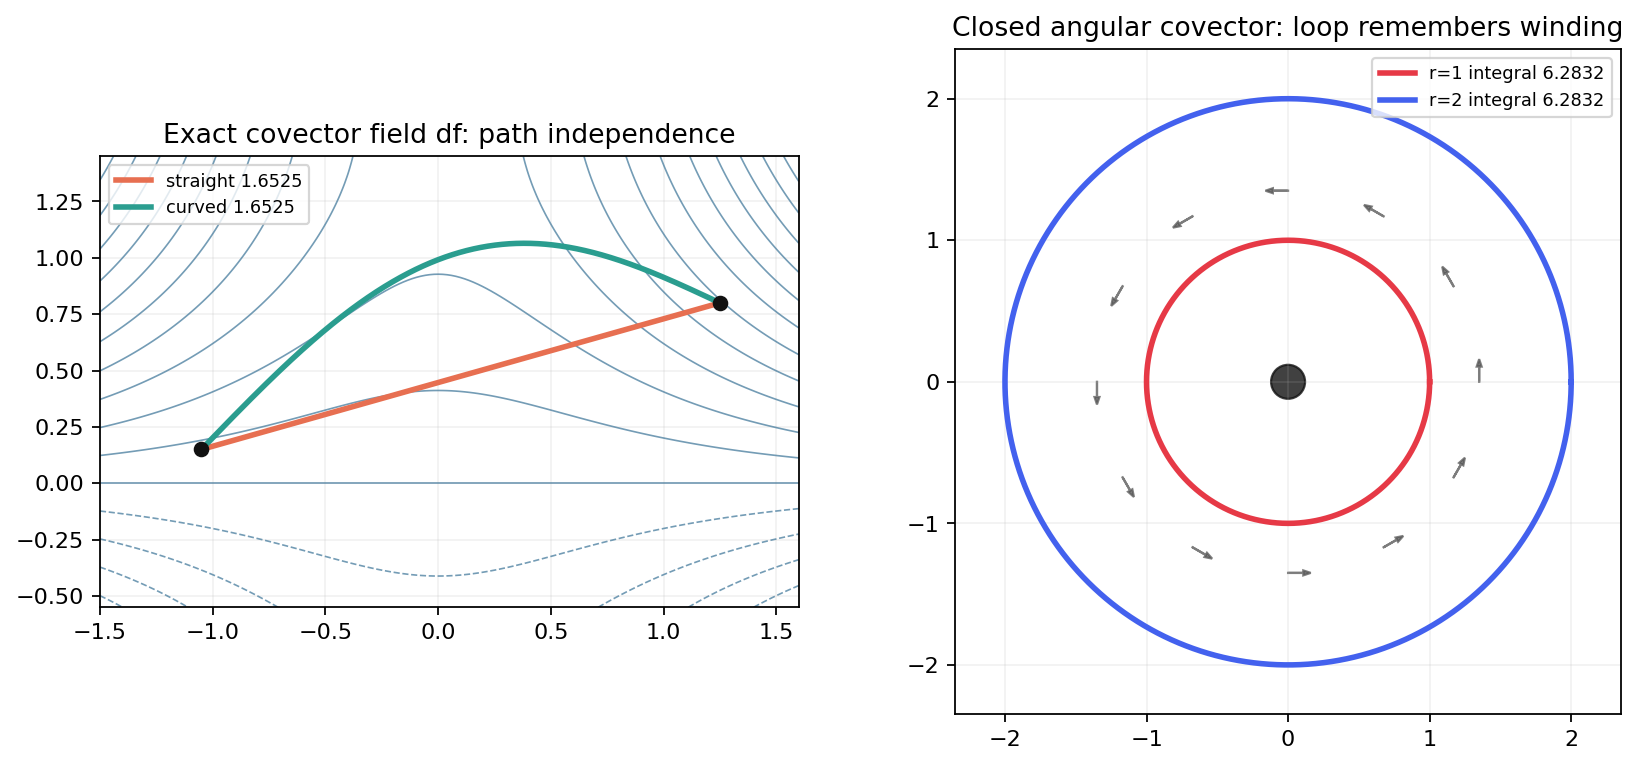

In [6]:
def potential_exact(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return x**2 * y + np.sin(y)


def exact_components(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return 2 * x * y, x**2 + np.cos(y)


def integrate_covector(path: np.ndarray, P_func, Q_func) -> float:
    """Midpoint segment quadrature for integral_gamma P dx + Q dy."""
    start, end = path[:-1], path[1:]
    mid = 0.5 * (start + end)
    delta = end - start
    P, Q = P_func(mid[:, 0], mid[:, 1]), Q_func(mid[:, 0], mid[:, 1])
    return float(np.sum(P * delta[:, 0] + Q * delta[:, 1]))


N = 1601
lam = np.linspace(0.0, 1.0, N)
A_pt = np.array([-1.05, 0.15])
B_pt = np.array([1.25, 0.8])
straight = (1 - lam)[:, None] * A_pt + lam[:, None] * B_pt
curved = straight.copy()
curved[:, 1] += 0.55 * np.sin(np.pi * lam)

straight_integral = integrate_covector(straight, lambda x, y: exact_components(x, y)[0], lambda x, y: exact_components(x, y)[1])
curved_integral = integrate_covector(curved, lambda x, y: exact_components(x, y)[0], lambda x, y: exact_components(x, y)[1])
endpoint_difference = float(potential_exact(B_pt[0], B_pt[1]) - potential_exact(A_pt[0], A_pt[1]))

circle_t = np.linspace(0.0, 2 * np.pi, N)
circle = np.column_stack([np.cos(circle_t), np.sin(circle_t)])
radius2 = np.column_stack([2 * np.cos(circle_t), 2 * np.sin(circle_t)])
angular_P = lambda x, y: -y / (x**2 + y**2)
angular_Q = lambda x, y: x / (x**2 + y**2)
unit_loop_integral = integrate_covector(circle, angular_P, angular_Q)
radius2_loop_integral = integrate_covector(radius2, angular_P, angular_Q)

x_sym, y_sym = sp.symbols("x y", real=True)
P_ang = -y_sym / (x_sym**2 + y_sym**2)
Q_ang = x_sym / (x_sym**2 + y_sym**2)
closed_residual_ang = sp.simplify(sp.diff(Q_ang, x_sym) - sp.diff(P_ang, y_sym))

plot_x = np.linspace(-1.5, 1.6, 160)
plot_y = np.linspace(-0.55, 1.45, 150)
XX, YY = np.meshgrid(plot_x, plot_y)
ZZ = potential_exact(XX, YY)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.4, 5.4))
ax0.contour(XX, YY, ZZ, levels=17, colors="#457b9d", linewidths=0.75, alpha=0.75)
ax0.plot(straight[:, 0], straight[:, 1], color="#e76f51", linewidth=2.5, label=f"straight {straight_integral:.4f}")
ax0.plot(curved[:, 0], curved[:, 1], color="#2a9d8f", linewidth=2.5, label=f"curved {curved_integral:.4f}")
ax0.scatter([A_pt[0], B_pt[0]], [A_pt[1], B_pt[1]], color="#111111", zorder=4)
ax0.set_title("Exact covector field df: path independence")
ax0.set_aspect("equal", adjustable="box")
ax0.grid(True, alpha=0.16)
ax0.legend(fontsize=8, loc="upper left")

ax1.add_patch(Circle((0, 0), 0.12, color="#111111", alpha=0.8))
ax1.plot(circle[:, 0], circle[:, 1], color="#e63946", linewidth=2.5, label=f"r=1 integral {unit_loop_integral:.4f}")
ax1.plot(radius2[:, 0], radius2[:, 1], color="#4361ee", linewidth=2.5, label=f"r=2 integral {radius2_loop_integral:.4f}")
for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    x0, y0 = 1.35 * np.cos(angle), 1.35 * np.sin(angle)
    ax1.arrow(x0, y0, -0.16 * np.sin(angle), 0.16 * np.cos(angle), head_width=0.035, color="#555555", length_includes_head=True, alpha=0.75)
ax1.set_title("Closed angular covector: loop remembers winding")
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlim(-2.35, 2.35)
ax1.set_ylim(-2.35, 2.35)
ax1.grid(True, alpha=0.16)
ax1.legend(fontsize=8, loc="upper right")

line_integral_fig = save_matplotlib(fig, FIGURES / "line-integrals-exact-vs-angular.png")
plt.close(fig)
artifacts.append(line_integral_fig)
line_integral_check_path = save_json({
    "exact_field": {
        "straight_integral": straight_integral,
        "curved_integral": curved_integral,
        "endpoint_difference": endpoint_difference,
        "max_path_error": max(abs(straight_integral - endpoint_difference), abs(curved_integral - endpoint_difference)),
    },
    "angular_field": {
        "closed_residual_dQdx_minus_dPdy": str(closed_residual_ang),
        "unit_loop_integral": unit_loop_integral,
        "radius2_loop_integral": radius2_loop_integral,
        "two_pi": float(2 * np.pi),
        "unit_loop_error": float(abs(unit_loop_integral - 2 * np.pi)),
        "radius2_loop_error": float(abs(radius2_loop_integral - 2 * np.pi)),
    },
}, CHECKS / "line-integral-exact-vs-angular.json")
check_paths.append(line_integral_check_path)
computed_checks["exact_line_integrals_path_independent"] = max(abs(straight_integral - endpoint_difference), abs(curved_integral - endpoint_difference)) < 2e-3
computed_checks["angular_form_closed_symbolically"] = closed_residual_ang == 0
computed_checks["angular_form_nonzero_loop"] = abs(unit_loop_integral - 2 * np.pi) < 2e-3
display_artifact(line_integral_fig, width=920)


In [7]:
windings = [0, 1, 2, -1]
fig = go.Figure()
winding_summary = []
for winding in windings:
    t_vals = np.linspace(0.0, 2 * np.pi, 800)
    radius = 1.0 + 0.08 * abs(winding)
    if winding == 0:
        theta_vals = 0.85 * np.sin(t_vals)
        cumulative = theta_vals - theta_vals[0]
    else:
        theta_vals = winding * t_vals
        cumulative = theta_vals - theta_vals[0]
    fig.add_trace(go.Scatter3d(
        x=radius * np.cos(theta_vals),
        y=radius * np.sin(theta_vals),
        z=cumulative,
        mode="lines",
        name=f"winding {winding}, integral {cumulative[-1]:.3f}",
        line=dict(width=6),
    ))
    winding_summary.append({"winding": winding, "predicted_integral": float(cumulative[-1]), "expected_2pi_w": float(2 * np.pi * winding)})

fig.update_layout(
    title="Angular covector cumulative integral: height equals accumulated dtheta",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="cumulative integral"),
    width=860,
    height=620,
    margin=dict(l=0, r=0, t=48, b=0),
)
angular_html = save_plotly_standalone(fig, HTML / "angular-form-winding-line-integrals.html")
artifacts.append(angular_html)
winding_table_path = save_csv(winding_summary, TABLES / "angular-form-winding-integrals.csv")
artifacts.append(winding_table_path)
computed_checks["plotly_winding_table_matches"] = all(abs(row["predicted_integral"] - row["expected_2pi_w"]) < 1e-12 for row in winding_summary if row["winding"] != 0)
display_artifact(angular_html, width=860, height=640)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Exact implies conservative because the fundamental theorem for line integrals collapses the integral to endpoint data. Conversely, a conservative covector field can be integrated from a fixed base point to build a potential. Closedness is only a local derivative test. On star-shaped domains it is enough to get exactness; on the punctured plane, the angular field is closed but not exact because the loop integral detects the missing point.


## 6. Exact, Conservative, Closed: A Classifier Table

For `P dx + Q dy` in the plane, closedness on a region where the coefficients are smooth means `dQ/dx - dP/dy = 0`. Exact fields are closed, but nonzero closed-loop integrals obstruct exactness.


In [8]:
field_rows = []
examples = [
    {"name": "exact polynomial df, f=x^2 y", "P": 2 * x_sym * y_sym, "Q": x_sym**2, "domain_note": "R^2", "sample_loop_integral": 0.0, "classification": "exact, conservative, closed"},
    {"name": "angular alpha=(-y dx+x dy)/(x^2+y^2)", "P": P_ang, "Q": Q_ang, "domain_note": "R^2 minus origin", "sample_loop_integral": unit_loop_integral, "classification": "closed but not exact on punctured plane"},
    {"name": "shear y dx", "P": y_sym, "Q": 0, "domain_note": "R^2", "sample_loop_integral": -1.0, "classification": "not closed, therefore not exact"},
]
for row in examples:
    residual = sp.simplify(sp.diff(row["Q"], x_sym) - sp.diff(row["P"], y_sym))
    field_rows.append({
        "field": row["name"],
        "domain": row["domain_note"],
        "closed_residual_dQdx_minus_dPdy": str(residual),
        "sample_closed_loop_integral": row["sample_loop_integral"],
        "classification": row["classification"],
    })

classifier_table_path = save_csv(field_rows, TABLES / "closed-exact-conservative-classification.csv")
artifacts.append(classifier_table_path)
classifier_check_path = save_json({"fields": field_rows}, CHECKS / "closed-exact-conservative-classification.json")
check_paths.append(classifier_check_path)
computed_checks["classifier_has_closed_nonexact_example"] = any("closed but not exact" in row["classification"] for row in field_rows)
computed_checks["not_closed_example_detected"] = any(row["closed_residual_dQdx_minus_dPdy"] != "0" and "not closed" in row["classification"] for row in field_rows)
pd.DataFrame(field_rows)


,field,domain,closed_residual_dQdx_minus_dPdy,sample_closed_loop_integral,classification
0,"exact polynomial df, f=x^2 y",R^2,0,0.000000,"exact, conservative, closed"
1,angular alpha=(-y dx+x dy)/(x^2+y^2),R^2 minus origin,0,6.283193,closed but not exact on punctured plane
2,shear y dx,R^2,-1,-1.000000,"not closed, therefore not exact"


## 7. Chapter 10 and Chapter 13 Connections

Chapter 10 gives the vector-bundle template. If a vector-bundle transition matrix is `A`, the dual bundle uses the inverse transpose so that pairings stay unchanged. Chapter 13 adds a Riemannian metric `g`, which gives a new isomorphism between tangent and cotangent fibers: the flat map `v -> g(v, .)` and its inverse sharp map. This bridge depends on `g`; the cotangent bundle itself does not.


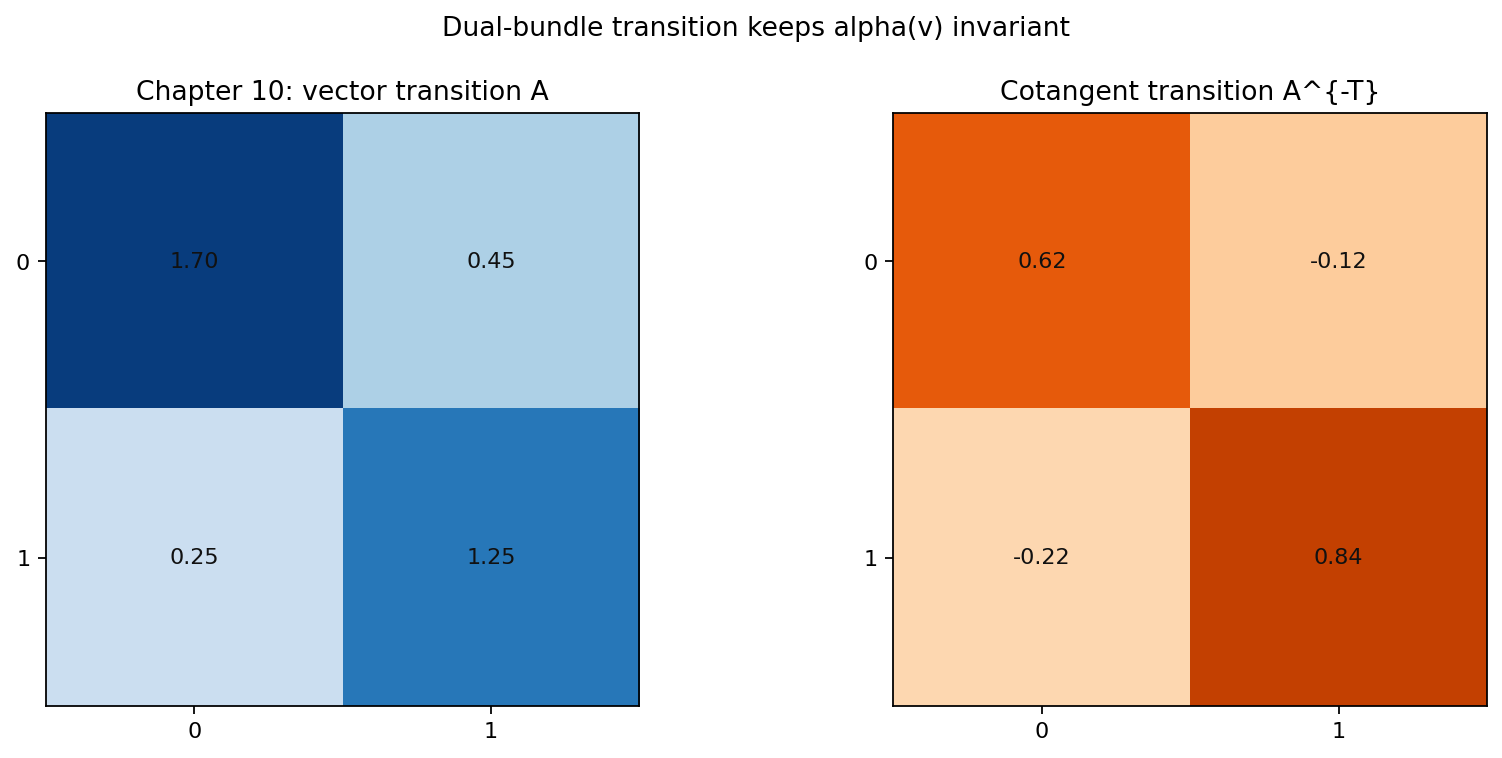

In [9]:
A = np.array([[1.7, 0.45], [0.25, 1.25]], dtype=float)
A_dual = np.linalg.inv(A).T
alpha_old = np.array([0.8, -1.4])
v_old = np.array([1.1, 0.35])
v_new = A @ v_old
alpha_new = A_dual @ alpha_old
bundle_pairing_error = float(abs(alpha_old @ v_old - alpha_new @ v_new))

G_metric = np.array([[2.0, 0.35], [0.35, 1.15]], dtype=float)
v_metric = np.array([0.6, -1.1])
alpha_flat = G_metric @ v_metric
v_sharp = np.linalg.solve(G_metric, alpha_flat)
metric_roundtrip_error = float(np.linalg.norm(v_sharp - v_metric))
metric_eigenvalues = np.linalg.eigvalsh(G_metric).tolist()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.8, 4.8))
ax0.imshow(A, cmap="Blues", vmin=-0.2, vmax=1.8)
ax0.set_title("Chapter 10: vector transition A")
ax0.set_xticks([0, 1]); ax0.set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        ax0.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center", color="#111111")
ax1.imshow(A_dual, cmap="Oranges", vmin=-0.6, vmax=1.2)
ax1.set_title("Cotangent transition A^{-T}")
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{A_dual[i,j]:.2f}", ha="center", va="center", color="#111111")
fig.suptitle("Dual-bundle transition keeps alpha(v) invariant")
fig.tight_layout()
bridge_fig = save_matplotlib(fig, FIGURES / "dual-bundle-metric-bridge.png")
plt.close(fig)
artifacts.append(bridge_fig)

relations_table_path = save_csv([
    {"relation": "dual bundle transition", "formula": "alpha_new = A^{-T} alpha_old", "check_value": bundle_pairing_error, "meaning": "natural pairing alpha(v) is frame independent"},
    {"relation": "metric flat map", "formula": "alpha_i = g_ij v^j", "check_value": metric_roundtrip_error, "meaning": "a Chapter 13 metric identifies T_pM with T_p^*M"},
    {"relation": "metric positive eigenvalues", "formula": "eig(g) > 0", "check_value": min(metric_eigenvalues), "meaning": "Riemannian metric gives an invertible flat/sharp bridge"},
], TABLES / "bundle-and-metric-relations.csv")
artifacts.append(relations_table_path)
relations_check_path = save_json({
    "vector_transition_A": A.tolist(),
    "dual_transition_A_inverse_transpose": A_dual.tolist(),
    "bundle_pairing_error": bundle_pairing_error,
    "metric_matrix": G_metric.tolist(),
    "metric_eigenvalues": metric_eigenvalues,
    "flat_covector": alpha_flat.tolist(),
    "sharp_roundtrip_error": metric_roundtrip_error,
}, CHECKS / "bundle-and-metric-relations.json")
check_paths.append(relations_check_path)
computed_checks["dual_bundle_pairing_invariant"] = bundle_pairing_error < 1e-12
computed_checks["metric_flat_sharp_roundtrip"] = metric_roundtrip_error < 1e-12
computed_checks["metric_positive_definite"] = min(metric_eigenvalues) > 0
display_artifact(bridge_fig, width=820)


The metric bridge explains a common misconception. In Euclidean calculus, gradients are often drawn as arrows because the Euclidean metric silently converts `df` into a vector. On a general smooth manifold, `df` is naturally a covector field first. The arrow requires extra metric data.


## Applied Lab: Change the Winding, Watch the Obstruction

The lab below fixes the angular covector field on the punctured plane and varies only the path. A closed path with zero winding has zero angular integral; a closed path winding `k` times has integral `2*pi*k`. That single integer separates local closedness from global exactness on this domain.


In [10]:
lab_rows = []
for winding in range(-2, 3):
    t_vals = np.linspace(0.0, 2 * np.pi, 2401)
    theta_vals = 0.6 * np.sin(t_vals) if winding == 0 else winding * t_vals
    radius = 1.3 + 0.12 * np.cos(3 * t_vals)
    path = np.column_stack([radius * np.cos(theta_vals), radius * np.sin(theta_vals)])
    integral = integrate_covector(path, angular_P, angular_Q)
    lab_rows.append({
        "winding": winding,
        "numeric_integral": integral,
        "expected_2pi_winding": float(2 * np.pi * winding),
        "absolute_error": float(abs(integral - 2 * np.pi * winding)),
    })

lab_table_path = save_csv(lab_rows, TABLES / "learner-lab-winding-table.csv")
artifacts.append(lab_table_path)
lab_check_path = save_json({"lab": lab_rows}, CHECKS / "learner-lab-winding-checks.json")
check_paths.append(lab_check_path)
computed_checks["learner_lab_winding_integrals"] = max(row["absolute_error"] for row in lab_rows) < 2.5e-3
pd.DataFrame(lab_rows)


,winding,numeric_integral,expected_2pi_winding,absolute_error
0,-2,-1.256640e+01,-12.566371,2.787867e-05
1,-1,-6.283188e+00,-6.283185,3.173231e-06
2,0,2.109424e-15,0.000000,2.109424e-15
3,1,6.283188e+00,6.283185,3.173231e-06
4,2,1.256640e+01,12.566371,2.787867e-05


## Final Sanity Checks

The final cell verifies the chapter coverage manifest, artifact existence and size, and the mathematical invariants used throughout the notebook. These checks do not replace proof, but they make the notebook falsifiable: if a coordinate formula, pullback identity, line integral, or artifact path goes stale, execution should fail.


In [11]:
required_storyboard = {
    "covector hyperplanes",
    "coordinate covectors and basis changes",
    "differential linear approximation",
    "pullback chain rule",
    "line integrals exact versus angular",
    "closed exact conservative classifier",
    "Chapter 10 vector bundle relation",
    "Chapter 13 metric relation",
    "applied winding lab",
}
implemented_storyboard = set(required_storyboard)

assert required_storyboard <= implemented_storyboard
assert "covectors" in chapter_terms and "Chapter 13 metrics" in chapter_terms
assert_artifacts(artifacts + check_paths, min_bytes=64)
for name, passed in computed_checks.items():
    assert bool(passed), f"Invariant failed: {name}"

final_sanity = {
    "unit_key": UNIT_KEY,
    "source_span": SOURCE_SPAN,
    "coverage_terms": sorted(chapter_terms),
    "storyboard_items_implemented": sorted(implemented_storyboard),
    "computed_checks": {name: bool(value) for name, value in sorted(computed_checks.items())},
    "artifact_count": len(artifacts),
    "check_file_count": len(check_paths),
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
print(json.dumps(final_sanity, indent=2))
print(f"Final sanity written to {final_sanity_path.relative_to(BOOK_ROOT)}")


{
  "unit_key": "chapter-11-the-cotangent-bundle",
  "source_span": {
    "printed_pages": "272-303",
    "pdf_pages_inspected": "290-321",
    "pdftotext_command": "pdftotext -f 290 -l 321 -layout 'Introduction to Smooth Manifolds.pdf' -"
  },
  "coverage_terms": [
    "Chapter 10 vector bundles",
    "Chapter 13 metrics",
    "basis changes",
    "closed non-exact covector fields",
    "conservative covector fields",
    "coordinate covectors",
    "cotangent spaces",
    "covectors",
    "differential of a function",
    "exact covector fields",
    "line integrals",
    "pullbacks"
  ],
  "storyboard_items_implemented": [
    "Chapter 10 vector bundle relation",
    "Chapter 13 metric relation",
    "applied winding lab",
    "closed exact conservative classifier",
    "coordinate covectors and basis changes",
    "covector hyperplanes",
    "differential linear approximation",
    "line integrals exact versus angular",
    "pullback chain rule"
  ],
  "computed_checks": {
    "ang

## Takeaways

- A cotangent vector is a linear measurement on tangent vectors; its kernel and unit affine hyperplane make the measurement visible.
- Coordinate covectors transform by pullback, so Jacobian transposes appear naturally and pairings stay invariant.
- The differential `df` is a covector field and is the coordinate-free first derivative of a real-valued function.
- Pullbacks of covector fields exist for every smooth map and satisfy the chain-rule identity `F^* dh = d(h o F)`.
- Line integrals of exact fields depend only on endpoints; closed fields can still fail to be exact globally, as the angular form on the punctured plane shows.
- Chapter 10 supplies the vector-bundle framework for `T^*M`; Chapter 13 explains when a metric can turn covectors into vectors.
